In [2]:
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Делаем графики и табличный вывод чуть удобнее для демонстрации в ноутбуке.
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [3]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

In [4]:
df = pd.read_csv('S12-hw-dataset.csv')
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [6]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    4320 non-null   object 
 1   target  4320 non-null   float64
dtypes: float64(1), object(1)
memory usage: 67.6+ KB


In [7]:
df.isna().sum()

date      0
target    0
dtype: int64

,count,mean,min,25%,50%,75%,max,std
date,4320,2025-03-31 23:29:59.999999744,2025-01-01 00:00:00,2025-02-14 23:45:00,2025-03-31 23:30:00,2025-05-15 23:15:00,2025-06-29 23:00:00,NaN
target,4320.0,135.60584,69.1,120.5375,135.835,150.625,210.1,21.384633


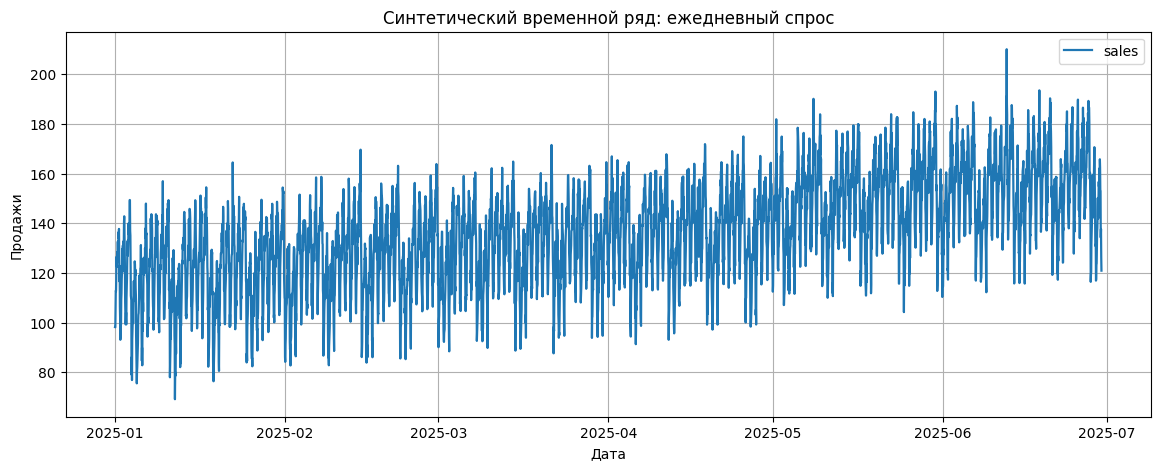

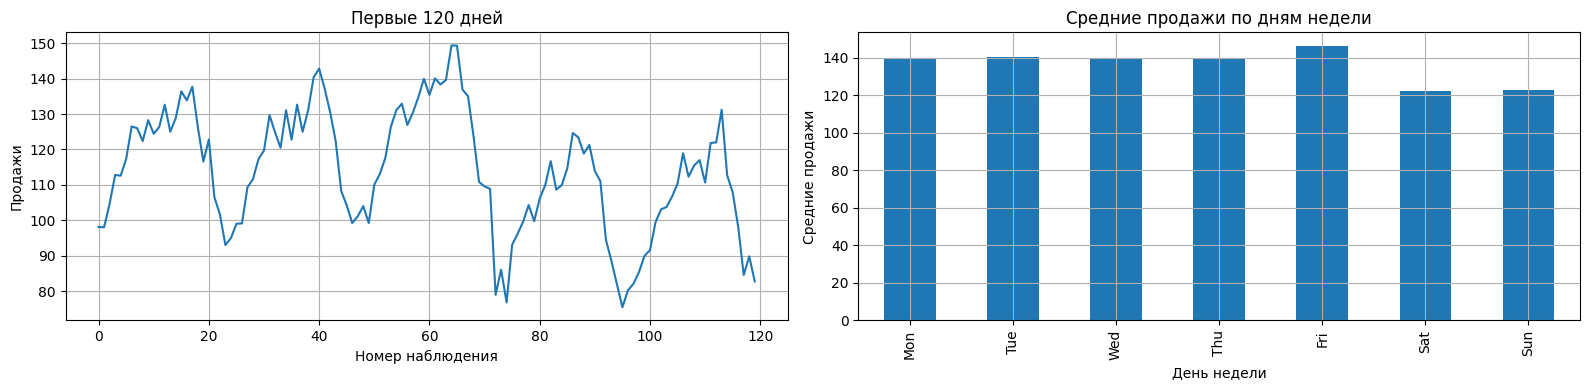

In [11]:
df['date'] = pd.to_datetime(df['date'])

display(df.describe(include="all").T)

fig, ax = plt.subplots()
ax.plot(df["date"], df["target"], lw=1.6, label="sales")
ax.set_title("Синтетический временной ряд: ежедневный спрос")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажи")
ax.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Крупным планом видно локальную динамику и уровень шума в начале ряда.
df["target"].iloc[:120].plot(ax=axes[0], title="Первые 120 дней")
axes[0].set_xlabel("Номер наблюдения")
axes[0].set_ylabel("Продажи")

dow_order = [0, 1, 2, 3, 4, 5, 6]
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
(
    df.assign(dayofweek=df["date"].dt.dayofweek)
      .groupby("dayofweek")["target"].mean()
      .reindex(dow_order)
      .set_axis(dow_names)
      .plot(kind="bar", ax=axes[1], title="Средние продажи по дням недели")
)
axes[1].set_xlabel("День недели")
axes[1].set_ylabel("Средние продажи")

plt.tight_layout()
plt.show()

train: 2025-01-01 → 2025-05-06 | 3024 строк
val:   2025-05-07 → 2025-06-02 | 648 строк
test:  2025-06-03 → 2025-06-29 | 648 строк


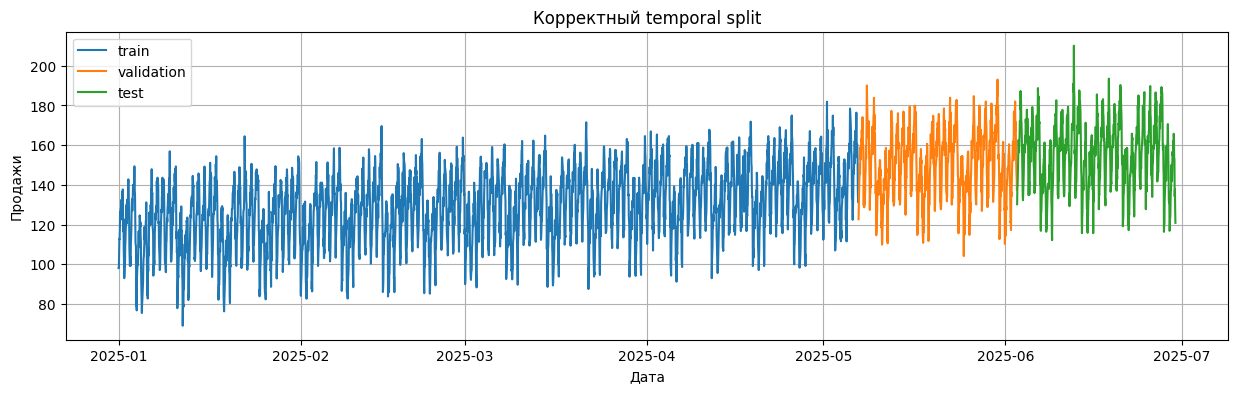

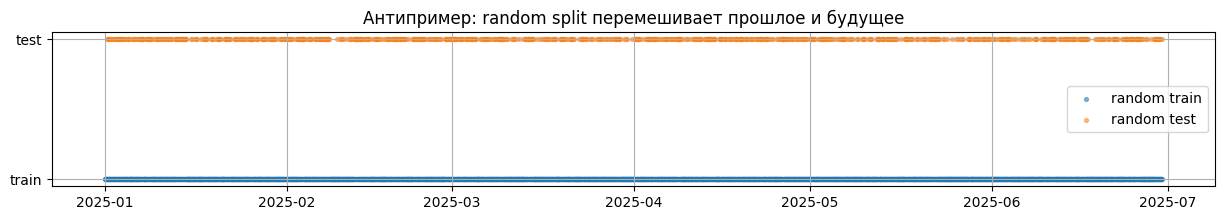

In [13]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    # Проверяем, что доли действительно покрывают весь датасет.
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    # Ключевая идея: train, validation и test идут по времени друг за другом.
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df['date'].min().date()} → {train_df['date'].max().date()} | {len(train_df)} строк")
print(f"val:   {val_df['date'].min().date()} → {val_df['date'].max().date()} | {len(val_df)} строк")
print(f"test:  {test_df['date'].min().date()} → {test_df['date'].max().date()} | {len(test_df)} строк")

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train_df["date"], train_df["target"], label="train")
ax.plot(val_df["date"], val_df["target"], label="validation")
ax.plot(test_df["date"], test_df["target"], label="test")
ax.set_title("Корректный temporal split")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажи")
ax.legend()
plt.show()

# Для контраста строим антипример: случайное разбиение перемешивает прошлое и будущее.
random_train_idx, random_test_idx = train_test_split(df.index, test_size=0.2, random_state=42, shuffle=True)

fig, ax = plt.subplots(figsize=(15, 2))
ax.scatter(df.loc[random_train_idx, "date"], np.zeros(len(random_train_idx)), s=8, alpha=0.5, label="random train")
ax.scatter(df.loc[random_test_idx, "date"], np.ones(len(random_test_idx)), s=8, alpha=0.5, label="random test")
ax.set_title("Антипример: random split перемешивает прошлое и будущее")
ax.set_yticks([0, 1])
ax.set_yticklabels(["train", "test"])
ax.legend()
plt.show()

In [15]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Календарные признаки часто дают модели простую и полезную сезонную структуру.
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month

    # Синус/косинус кодируют цикличность без искусственного разрыва между концом и началом периода.
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)

    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    return out

def add_lag_features(df: pd.DataFrame, target_col: str = "sales") -> pd.DataFrame:
    out = df.copy()

    # Лаги смотрят только назад во времени и поэтому безопасны с точки зрения leakage.
    for lag in [1, 2, 3, 7, 14, 28]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)

    # Перед rolling используем shift(1), чтобы статистика не включала текущее наблюдение.
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    out["rolling_mean_28"] = out[target_col].shift(1).rolling(window=28).mean()
    out["rolling_std_28"] = out[target_col].shift(1).rolling(window=28).std()
    return out

features_df = add_calendar_features(df)
features_df = add_lag_features(features_df, 'target')

# Первые строки неизбежно теряются из-за лагов и rolling-окон.
features_df = features_df.dropna().reset_index(drop=True)
features_df.head()

,date,target,dayofweek,month,dow_sin,dow_cos,month_sin,month_cos,lag_1,lag_2,lag_3,lag_7,lag_14,lag_28,rolling_mean_7,rolling_std_7,rolling_mean_28,rolling_std_28
0,2025-01-02 04:00:00,111.64,3,1,0.433884,-0.900969,0.5,0.866025,109.33,99.14,99.05,106.54,128.87,98.14,100.545714,5.856307,116.487143,13.778753
1,2025-01-02 05:00:00,117.30,3,1,0.433884,-0.900969,0.5,0.866025,111.64,109.33,99.14,101.72,136.40,98.07,101.274286,6.942790,116.969286,13.342257
2,2025-01-02 06:00:00,119.72,3,1,0.433884,-0.900969,0.5,0.866025,117.30,111.64,109.33,93.04,133.85,104.70,103.500000,9.230043,117.656071,12.818023
3,2025-01-02 07:00:00,129.68,3,1,0.433884,-0.900969,0.5,0.866025,119.72,117.30,111.64,95.00,137.71,112.81,107.311429,9.688052,118.192500,12.567579
4,2025-01-02 08:00:00,124.85,3,1,0.433884,-0.900969,0.5,0.866025,129.68,119.72,117.30,99.05,126.32,112.62,112.265714,11.106433,118.795000,12.703625


In [16]:
feature_cols = [
    
    "dayofweek", "month",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_std_7", "rolling_mean_28", "rolling_std_28",
]

target_col = "target"

# Разбиение выполняем после построения признаков, но без перемешивания по времени.
train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]

X_val = val_feat[feature_cols]
y_val = val_feat[target_col]

X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

print("Размерности:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

Размерности:
X_train: (3004, 16) | y_train: (3004,)
X_val:   (644, 16) | y_val:   (644,)
X_test:  (644, 16) | y_test:  (644,)


In [17]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def evaluate_regression(y_true, y_pred, model_name: str) -> pd.DataFrame:
    return pd.DataFrame([{
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
    }])

# Naive baseline: завтрашнее значение равно последнему наблюдённому.
val_pred_naive = val_feat["lag_1"].to_numpy()
test_pred_naive = test_feat["lag_1"].to_numpy()

# Moving average baseline: вместо одного прошлого значения берём короткое среднее окно.
val_pred_ma7 = val_feat["rolling_mean_7"].to_numpy()
test_pred_ma7 = test_feat["rolling_mean_7"].to_numpy()

baseline_results_val = pd.concat([
    evaluate_regression(y_val, val_pred_naive, "Naive (lag_1)"),
    evaluate_regression(y_val, val_pred_ma7, "MovingAverage(7)"),
], ignore_index=True)

baseline_results_test = pd.concat([
    evaluate_regression(y_test, test_pred_naive, "Naive (lag_1)"),
    evaluate_regression(y_test, test_pred_ma7, "MovingAverage(7)"),
], ignore_index=True)

print("Validation:")
display(baseline_results_val)

print("Test:")
display(baseline_results_test)

Validation:


,model,MAE,RMSE,MAPE_%
0,Naive (lag_1),6.441118,8.207078,4.393620
1,MovingAverage(7),12.697560,15.226533,8.812577


Test:


,model,MAE,RMSE,MAPE_%
0,Naive (lag_1),6.346786,8.069082,4.148819
1,MovingAverage(7),12.750535,15.247658,8.550916


## B3

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# Деревья к масштабу почти нечувствительны, поэтому RandomForest оставляем на исходных признаках.
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

val_pred_ridge = ridge.predict(X_val_scaled)
test_pred_ridge = ridge.predict(X_test_scaled)

val_pred_rf = rf.predict(X_val)
test_pred_rf = rf.predict(X_test)

# Сравниваем модели на validation и test в единой таблице метрик.
val_results = pd.concat([
    baseline_results_val,
    evaluate_regression(y_val, val_pred_ridge, "Ridge"),
    evaluate_regression(y_val, val_pred_rf, "RandomForest"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

test_results = pd.concat([
    baseline_results_test,
    evaluate_regression(y_test, test_pred_ridge, "Ridge"),
    evaluate_regression(y_test, test_pred_rf, "RandomForest"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

print("Validation:")
display(val_results)

print("Test:")
display(test_results)

Validation:


,model,MAE,RMSE,MAPE_%
0,Ridge,5.139286,6.590869,3.449630
1,Naive (lag_1),6.441118,8.207078,4.393620
2,RandomForest,7.305716,9.149553,4.833627
3,MovingAverage(7),12.697560,15.226533,8.812577


Test:


,model,MAE,RMSE,MAPE_%
0,Ridge,4.877414,6.324662,3.196007
1,Naive (lag_1),6.346786,8.069082,4.148819
2,RandomForest,9.124479,11.277840,5.753863
3,MovingAverage(7),12.750535,15.247658,8.550916


Лучшая модель на test по MAE: Ridge


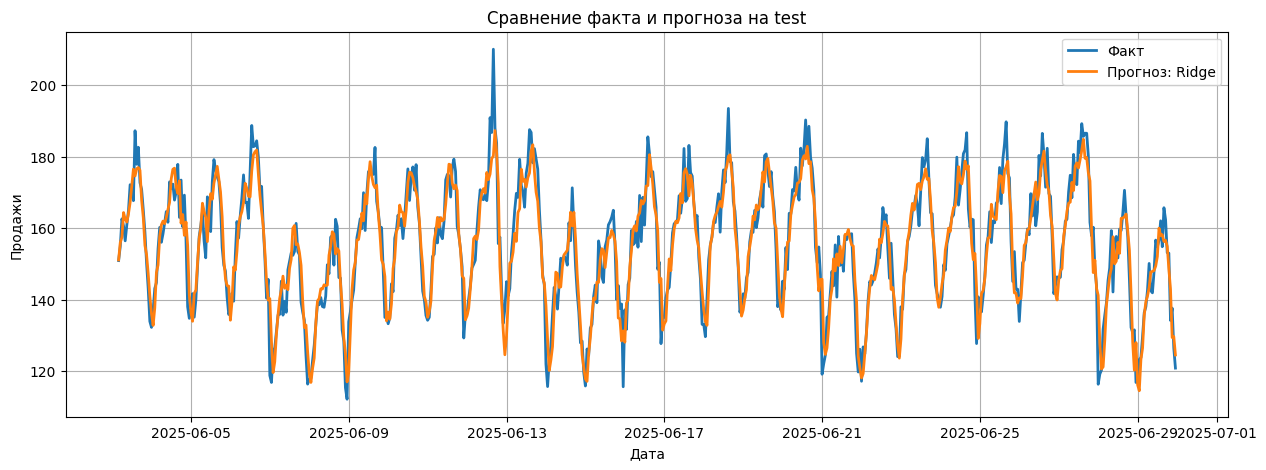

,date,actual,prediction,abs_error
0,2025-06-03 04:00:00,150.98,151.158175,0.178175
1,2025-06-03 05:00:00,154.94,155.988511,1.048511
2,2025-06-03 06:00:00,162.64,157.505621,5.134379
3,2025-06-03 07:00:00,160.66,164.411443,3.751443
4,2025-06-03 08:00:00,156.50,162.539200,6.039200
5,2025-06-03 09:00:00,160.98,161.747944,0.767944
6,2025-06-03 10:00:00,165.02,164.082467,0.937533
7,2025-06-03 11:00:00,172.20,167.236812,4.963188
8,2025-06-03 12:00:00,171.81,171.996425,0.186425
9,2025-06-03 13:00:00,167.73,176.547935,8.817935


,date,actual,prediction,abs_error
228,2025-06-12 16:00:00,210.10,180.220439,29.879561
428,2025-06-21 00:00:00,119.18,145.750274,26.570274
596,2025-06-28 00:00:00,116.38,141.260648,24.880648
92,2025-06-07 00:00:00,118.82,140.331129,21.511129
330,2025-06-16 22:00:00,127.74,145.957585,18.217585
42,2025-06-04 22:00:00,138.05,155.194336,17.144336
231,2025-06-12 19:00:00,155.72,172.595973,16.875973
210,2025-06-11 22:00:00,129.32,146.003916,16.683916
260,2025-06-14 00:00:00,122.04,138.474066,16.434066
226,2025-06-12 14:00:00,190.95,175.165600,15.784400


In [19]:
# Берём победителя по MAE на test и визуально проверяем, где именно он ошибается.
best_model_name = test_results.iloc[0]["model"]
pred_map = {
    "Naive (lag_1)": test_pred_naive,
    "MovingAverage(7)": test_pred_ma7,
    "Ridge": test_pred_ridge,
    "RandomForest": test_pred_rf,
}
best_test_pred = pred_map[best_model_name]

print(f"Лучшая модель на test по MAE: {best_model_name}")

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(test_feat["date"], y_test.to_numpy(), label="Факт", lw=2)
ax.plot(test_feat["date"], best_test_pred, label=f"Прогноз: {best_model_name}", lw=2)
ax.set_title("Сравнение факта и прогноза на test")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажи")
ax.legend()
plt.show()

comparison_df = pd.DataFrame({
    "date": test_feat["date"].values,
    "actual": y_test.to_numpy(),
    "prediction": best_test_pred,
})
comparison_df["abs_error"] = np.abs(comparison_df["actual"] - comparison_df["prediction"])

# Смотрим и первые наблюдения, и самые крупные промахи модели.
display(comparison_df.head(10))
display(comparison_df.sort_values("abs_error", ascending=False).head(10))

## B4

In [24]:
# PyTorch для построения и обучения нейросетей
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

In [28]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Определяем устройство: используем GPU если доступен, иначе CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [21]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)  # fit на train
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)          # transform для val/test
test_scaled = scaler.transform(test_df[["target"]]).astype(np.float32)

window_size = 28  # Глубина контекста: модель смотрит на 28 дней в прошлое

def make_windows(series_2d: np.ndarray, window_size: int):
    """
    Преобразует временной ряд в обучающие примеры вида (X, y).
    Каждый пример X: окно из window_size значений
    Каждый пример y: следующее значение после окна
    Например: X = [day1..day28], y = day29
    """
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])        # Окно длины 28
        y.append(series_2d[i + window_size, 0])         # Цель: день 29
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Создаем обучающие примеры для каждого набора
X_train, y_train = make_windows(train_scaled, window_size)
X_val, y_val = make_windows(val_scaled, window_size)
X_test, y_test = make_windows(test_scaled, window_size)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (2996, 28, 1) y_train: (2996,)
X_val  : (620, 28, 1) y_val  : (620,)
X_test : (620, 28, 1) y_test : (620,)


Форма одного окна: (28, 1)
Первые 5 значений окна: [-1.6267993  -1.6305869  -1.2718506  -0.8330344  -0.84331495]
Цель: -0.8963408


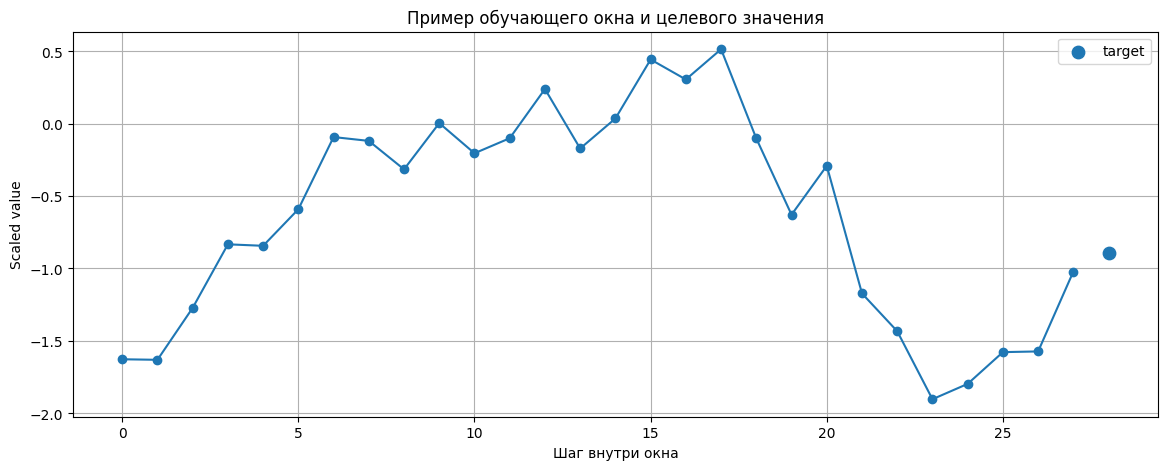

In [22]:
sample_idx = 0

print("Форма одного окна:", X_train[sample_idx].shape)
print("Первые 5 значений окна:", X_train[sample_idx][:5].ravel())
print("Цель:", y_train[sample_idx])

fig, ax = plt.subplots()
ax.plot(np.arange(window_size), X_train[sample_idx].ravel(), marker="o")
ax.scatter([window_size], [y_train[sample_idx]], s=80, label="target")
ax.set_title("Пример обучающего окна и целевого значения")
ax.set_xlabel("Шаг внутри окна")
ax.set_ylabel("Scaled value")
ax.legend()
plt.show()

In [25]:
class TimeSeriesDataset(Dataset):
    """Оборачивает массивы X, y в PyTorch Dataset для использования с DataLoader."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  # (num_samples, window_size, 1)
        self.y = torch.tensor(y, dtype=torch.float32)  # (num_samples,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

batch_size = 64  # Размер батча для градиентного спуска

# Создаем датасеты для каждого набора
train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)
test_ds = TimeSeriesDataset(X_test, y_test)

# Создаем DataLoaders для итерирования по батчам
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)   # train перемешиваем
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)      # val не перемешиваем
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# Проверяем форму батча
xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)  # (batch_size, window_size, 1)
print("Batch y:", yb.shape)  # (batch_size,)

Batch X: torch.Size([64, 28, 1])
Batch y: torch.Size([64])


In [26]:
class GRUForecaster(nn.Module):
    """
    GRU-модель для временных рядов.
    GRU проще, чем LSTM: имеет 2 вентиля (reset и update) вместо 3, нет cell state.
    Часто работает лучше на малых датасетах благодаря меньшей сложности оптимизации.
    """
    def __init__(self, input_size: int = 1, hidden_size: int = 48, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred

In [29]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Обучает модель на одной эпохе.
    1. Переводим в режим train
    2. Проходим по всем батчам
    3. Вычисляем loss и обновляем веса
    4. Возвращаем среднее значение loss
    """
    model.train()  # Режим обучения (включающий dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    """
    Оценивает модель на валидации/тесте без обновления весов.
    @torch.no_grad() отключает вычисление градиентов (экономит память и время).
    """
    model.eval()  # Режим оценки (отключаем dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))


def fit_model(model, train_loader, val_loader, epochs=12, lr=1e-3, device=device):
    """
    Полный цикл обучения с ранней остановкой.
    Сохраняет лучшее состояние модели (когда val_loss был минимален).
    """
    criterion = nn.MSELoss()  # Mean Squared Error loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Adam optimizer

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        # 1. Обучение на train
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        # 2. Оценка на validation
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # 3. Отслеживаем лучший результат
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()  # Сохраняем веса при лучшем val_loss

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # 4. Восстанавливаем лучшее состояние модели
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [30]:
set_seed(42)
gru_model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
print("GRU  params:", sum(p.numel() for p in gru_model.parameters()))
gru_history = fit_model(gru_model, train_loader, val_loader, epochs=30, lr=5e-4, device=device)

GRU  params: 37889
Epoch 01 | train_loss=0.6994 | val_loss=0.6024
Epoch 02 | train_loss=0.2726 | val_loss=0.3549
Epoch 03 | train_loss=0.1632 | val_loss=0.2236
Epoch 04 | train_loss=0.1544 | val_loss=0.1980
Epoch 05 | train_loss=0.1512 | val_loss=0.1802
Epoch 06 | train_loss=0.1503 | val_loss=0.2615
Epoch 07 | train_loss=0.1463 | val_loss=0.2079
Epoch 08 | train_loss=0.1483 | val_loss=0.1745
Epoch 09 | train_loss=0.1463 | val_loss=0.3428
Epoch 10 | train_loss=0.1450 | val_loss=0.1793
Epoch 11 | train_loss=0.1419 | val_loss=0.2051
Epoch 12 | train_loss=0.1410 | val_loss=0.2272
Epoch 13 | train_loss=0.1373 | val_loss=0.2138
Epoch 14 | train_loss=0.1347 | val_loss=0.2043
Epoch 15 | train_loss=0.1305 | val_loss=0.2379
Epoch 16 | train_loss=0.1248 | val_loss=0.2244
Epoch 17 | train_loss=0.1172 | val_loss=0.1987
Epoch 18 | train_loss=0.1112 | val_loss=0.2192
Epoch 19 | train_loss=0.1129 | val_loss=0.1705
Epoch 20 | train_loss=0.1042 | val_loss=0.1719
Epoch 21 | train_loss=0.1053 | val_loss=0

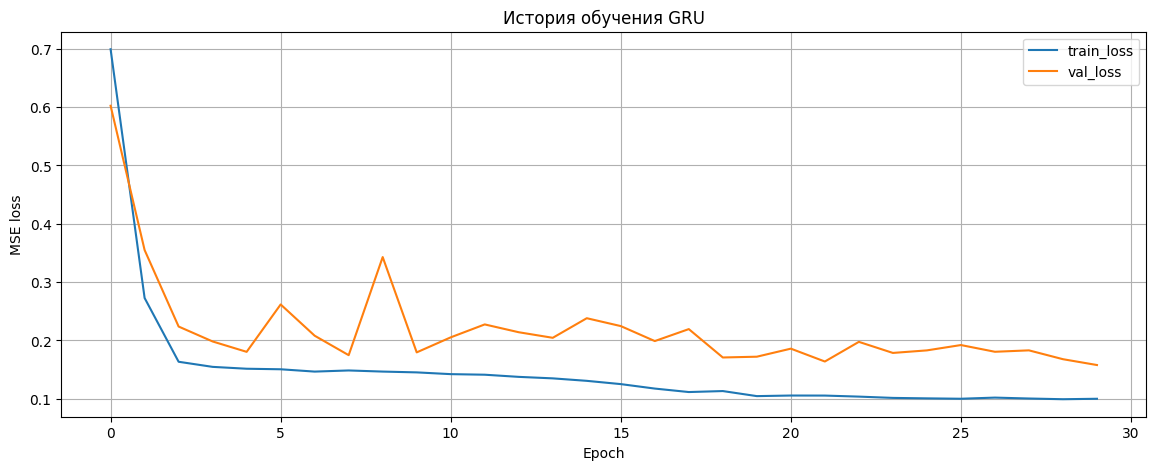

In [31]:
fig, ax = plt.subplots()
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.show()



In [33]:
@torch.no_grad()
def predict_model(model, loader, device):
    """
    Получает предсказания модели на батчах.
    Возвращает предсказания и истинные значения (в масштабированном пространстве).
    """
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()  # Переводим в numpy
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets


def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """Преобразует нормализованные значения обратно в исходный масштаб."""
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Вычисляет три основные метрики для регрессии:
    - MAE (Mean Absolute Error): средняя абсолютная ошибка в исходном масштабе
    - RMSE (Root Mean Squared Error): корень из среднеквадратичной ошибки
    - MAPE (Mean Absolute Percentage Error): средняя абсолютная процентная ошибка (%)
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}


def naive_baseline_from_windows(X: np.ndarray) -> np.ndarray:
    """
    Простой baseline: для каждого окна предсказываем последнее значение.
    Часто это хороший опорный результат для временных рядов.
    """
    return X[:, -1, 0]

# Получаем предсказания всех трех моделей на validation

gru_val_pred_scaled, gru_val_true_scaled = predict_model(gru_model, val_loader, device)
naive_val_pred_scaled = naive_baseline_from_windows(X_val)

# Восстанавливаем исходный масштаб
val_true = inverse_scale(gru_val_true_scaled, scaler)
gru_val_pred = inverse_scale(gru_val_pred_scaled, scaler)
naive_val_pred = inverse_scale(naive_val_pred_scaled, scaler)

# Вычисляем метрики для каждой модели и сортируем по RMSE
val_metrics = pd.DataFrame(
    [
        {"model": "Naive baseline", **regression_metrics(val_true, naive_val_pred)},
        
        {"model": "GRU", **regression_metrics(val_true, gru_val_pred)},
    ]
).sort_values("RMSE")

val_metrics

,model,MAE,RMSE,MAPE
1,GRU,5.720355,7.372209,3.862717
0,Naive baseline,6.454645,8.239123,4.400688


In [34]:
# Оценка моделей на TEST (финальная проверка, на которую модель не смотрела во время обучения)

gru_test_pred_scaled, gru_test_true_scaled = predict_model(gru_model, test_loader, device)
naive_test_pred_scaled = naive_baseline_from_windows(X_test)

# Восстанавливаем исходный масштаб
test_true = inverse_scale(gru_test_true_scaled, scaler)

gru_test_pred = inverse_scale(gru_test_pred_scaled, scaler)
naive_test_pred = inverse_scale(naive_test_pred_scaled, scaler)

# Вычисляем финальные метрики
test_metrics = pd.DataFrame(
    [
        {"model": "Naive baseline", **regression_metrics(test_true, naive_test_pred)},
        
        {"model": "GRU", **regression_metrics(test_true, gru_test_pred)},
    ]
).sort_values("RMSE")

test_metrics

,model,MAE,RMSE,MAPE
0,Naive baseline,6.366645,8.107879,4.168898
1,GRU,6.944059,8.805502,4.462556


Лучшая модель на test: Naive baseline


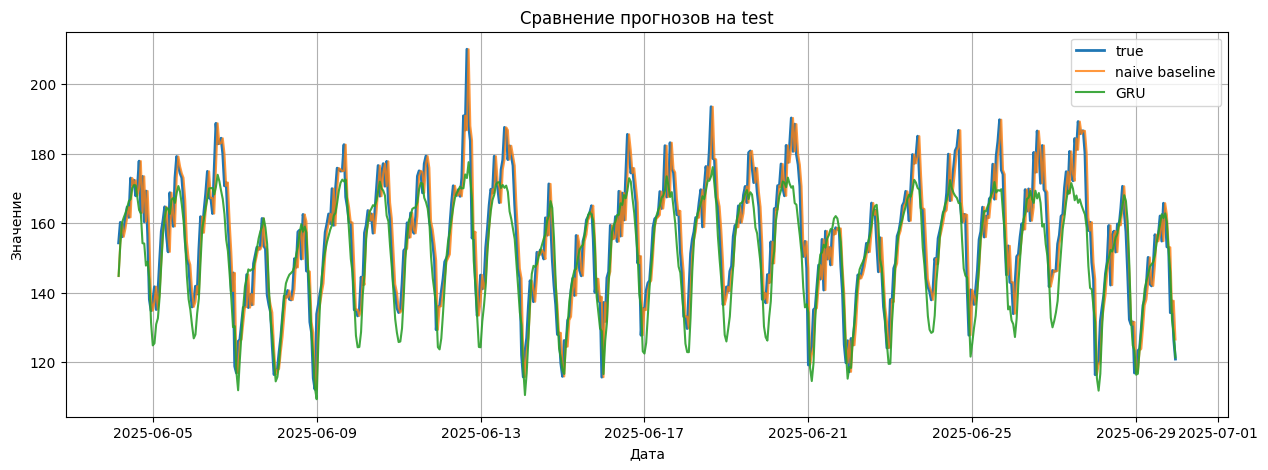

In [43]:
best_model_name = test_metrics.iloc[0]["model"]
print("Лучшая модель на test:", best_model_name)

# Объединяем даты и предсказания в одной таблице
plot_df = pd.DataFrame(
    {
        "date": test_df["date"].iloc[window_size:].reset_index(drop=True),
        "true": test_true,
        "naive": naive_test_pred,
        
        "gru": gru_test_pred,
    }
)

# Строим полные прогнозы всех трех подходов
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(plot_df["date"], plot_df["true"], label="true", lw=2)
ax.plot(plot_df["date"], plot_df["naive"], label="naive baseline", alpha=0.8)

ax.plot(plot_df["date"], plot_df["gru"], label="GRU", alpha=0.9)
ax.set_title("Сравнение прогнозов на test")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.show()

In [42]:
# Сохранение результатов экспериментов в runs.csv

# Создаем список всех экспериментов
experiments = []

# B1 - Naive (lag_1)
experiments.append({
    "experiment_id": "B1",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": 42,
    "split_summary": "temporal_split 70/15/15",
    "window_size": None,
    "horizon": 1,
    "model_summary": "Naive (lag_1)",
    "features_summary": "lag_1",
    "scaler": None,
    "optimizer": None,
    "lr": None,
    "epochs_trained": None,
    "best_val_mae": baseline_results_val.loc[0, "MAE"],
    "best_val_rmse": baseline_results_val.loc[0, "RMSE"],
    "best_val_mape": baseline_results_val.loc[0, "MAPE_%"],
    "test_mae": baseline_results_test.loc[0, "MAE"],
    "test_rmse": baseline_results_test.loc[0, "RMSE"],
    "test_mape": baseline_results_test.loc[0, "MAPE_%"],
    "notes": "Baseline: predict next value = last observed value"
})

# B1 - Moving Average (7)
experiments.append({
    "experiment_id": "B1",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": 42,
    "split_summary": "temporal_split 70/15/15",
    "window_size": 7,
    "horizon": 1,
    "model_summary": "MovingAverage(7)",
    "features_summary": "rolling_mean_7",
    "scaler": None,
    "optimizer": None,
    "lr": None,
    "epochs_trained": None,
    "best_val_mae": baseline_results_val.loc[1, "MAE"],
    "best_val_rmse": baseline_results_val.loc[1, "RMSE"],
    "best_val_mape": baseline_results_val.loc[1, "MAPE_%"],
    "test_mae": baseline_results_test.loc[1, "MAE"],
    "test_rmse": baseline_results_test.loc[1, "RMSE"],
    "test_mape": baseline_results_test.loc[1, "MAPE_%"],
    "notes": "Baseline: 7-day moving average"
})

# B2 - Ridge Regression
ridge_val_metrics = val_results[val_results["model"] == "Ridge"].iloc[0]
ridge_test_metrics = test_results[test_results["model"] == "Ridge"].iloc[0]

experiments.append({
    "experiment_id": "B2",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": 42,
    "split_summary": "temporal_split 70/15/15",
    "window_size": None,
    "horizon": 1,
    "model_summary": "Ridge",
    "features_summary": "calendar + lags + rolling stats (16 features)",
    "scaler": "StandardScaler",
    "optimizer": None,
    "lr": None,
    "epochs_trained": None,
    "best_val_mae": ridge_val_metrics["MAE"],
    "best_val_rmse": ridge_val_metrics["RMSE"],
    "best_val_mape": ridge_val_metrics["MAPE_%"],
    "test_mae": ridge_test_metrics["MAE"],
    "test_rmse": ridge_test_metrics["RMSE"],
    "test_mape": ridge_test_metrics["MAPE_%"],
    "notes": "Linear regression with L2 regularization"
})

# B3 - Random Forest
rf_val_metrics = val_results[val_results["model"] == "RandomForest"].iloc[0]
rf_test_metrics = test_results[test_results["model"] == "RandomForest"].iloc[0]

experiments.append({
    "experiment_id": "B3",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": 42,
    "split_summary": "temporal_split 70/15/15",
    "window_size": None,
    "horizon": 1,
    "model_summary": "RandomForest",
    "features_summary": "calendar + lags + rolling stats (16 features)",
    "scaler": None,
    "optimizer": None,
    "lr": None,
    "epochs_trained": None,
    "best_val_mae": rf_val_metrics["MAE"],
    "best_val_rmse": rf_val_metrics["RMSE"],
    "best_val_mape": rf_val_metrics["MAPE_%"],
    "test_mae": rf_test_metrics["MAE"],
    "test_rmse": rf_test_metrics["RMSE"],
    "test_mape": rf_test_metrics["MAPE_%"],
    "notes": "Random Forest with 300 trees, max_depth=10, min_samples_leaf=3"
})

# R1 - GRU
gru_test_metrics_dict = test_metrics[test_metrics["model"] == "GRU"].iloc[0]

experiments.append({
    "experiment_id": "R1",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": 42,
    "split_summary": "temporal_split 70/15/15",
    "window_size": 28,
    "horizon": 1,
    "model_summary": "GRU(hidden_size=64, num_layers=2)",
    "features_summary": "only target (univariate)",
    "scaler": "StandardScaler",
    "optimizer": "Adam",
    "lr": 0.0005,
    "epochs_trained": 30,
    "best_val_mae": 5.720355,
    "best_val_rmse": 7.372209,
    "best_val_mape": 3.862717,
    "test_mae": gru_test_metrics_dict["MAE"],
    "test_rmse": gru_test_metrics_dict["RMSE"],
    "test_mape": gru_test_metrics_dict["MAPE"],
    "notes": "GRU model trained with early stopping, best state restored"
})

# Сохраняем результаты в CSV
results_df = pd.DataFrame(experiments)
results_df.to_csv("artifacts/runs.csv", index=False)
print("Results saved to runs.csv")

# Сохраняем лучшую GRU модель
import json

# Сохраняем state_dict
torch.save(gru_model.state_dict(), "artifacts/best_gru.pt")
print("Model saved to best_gru.pt")

# Сохраняем конфигурацию модели
config = {
    "model_type": "GRU",
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.0,
    "window_size": 28,
    "batch_size": 64,
    "learning_rate": 0.0005,
    "epochs": 30,
    "seed": 42,
    "scaler": "StandardScaler",
    "loss_function": "MSE",
    "optimizer": "Adam",
    "early_stopping_patience": None,
    "best_val_mae": 5.720355,
    "best_val_rmse": 7.372209,
    "best_val_mape": 3.862717
}

with open("artifacts/best_gru_config.json", "w") as f:
    json.dump(config, f, indent=2)
print("Config saved to best_gru_config.json")

# Сохраняем графики
import os

# Создаем папку для графиков
os.makedirs("homeworks/HW12/artifacts/figures", exist_ok=True)



print("\nAll artifacts saved successfully!")

Results saved to runs.csv
Model saved to best_gru.pt
Config saved to best_gru_config.json

All artifacts saved successfully!
